### Pipeline LLM : Embeddings sémantiques + Classification


| ID | Représentation | Classifier | Tier |
|----|---------------|------------|------|
| B1 | LLM embedding (full precision) | Régression Logistique | Tier 1 |
| B2 | LLM embedding (8-bit quantifié) | Régression Logistique | Tier 1 |
| C2 | LLM embedding (full) | Isolation Forest | Tier 2 |
| T3 | LLM embedding (full) | RF / SVM | Tier 3 |


#### 0. Chargement des données et résultats ML


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import json
import time
import os
from collections import Counter

# Chemins
OUTPUT_DIR = "../outputs/"

# Chargement des sessions enrichies
with open(os.path.join(OUTPUT_DIR, "parsed_sessions.pkl"), 'rb') as f:
    enriched_sessions = pickle.load(f)

# Chargement du split train/test partagé
with open(os.path.join(OUTPUT_DIR, "train_test_split.pkl"), 'rb') as f:
    split_data = pickle.load(f)

# Chargement des résultats ML (pour comparaison visuelle)
with open(os.path.join(OUTPUT_DIR, "ml_results.pkl"), 'rb') as f:
    ml_results = pickle.load(f)

# Chargement du mapping des templates
with open(os.path.join(OUTPUT_DIR, "template_mapping.json"), 'r') as f:
    template_mapping = json.load(f)

# Variables partagées
block_ids = split_data['block_ids']
train_idx = split_data['train_idx']
test_idx = split_data['test_idx']
labels = split_data['labels']
sequence_strings = split_data['sequence_strings']

y_train = [labels[i] for i in train_idx]
y_test = [labels[i] for i in test_idx]

print(f"Sessions chargées :      {len(enriched_sessions):,}")
print(f"Train / Test :           {len(train_idx):,} / {len(test_idx):,}")
print(f"Templates disponibles :  {len(template_mapping)}")



Sessions chargées :      575,061
Train / Test :           460,048 / 115,013
Templates disponibles :  47


#### 1. Extraction des embeddings — Modèle pré-entraîné

In [2]:
from sentence_transformers import SentenceTransformer

# Chargement du modèle pré-entraîné
model = SentenceTransformer('all-MiniLM-L6-v2')
emb_dim = model.get_sentence_embedding_dimension()

print(f"Modèle :     all-MiniLM-L6-v2")
print(f"Dimension :  {emb_dim}")
print(f"Paramètres : ~22M")
print(f"Fine-tuning : Non")

/Users/sophia/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


Modèle :     all-MiniLM-L6-v2
Dimension :  384
Paramètres : ~22M
Fine-tuning : Non


#### 1.1 Aperçu des templates à encoder

In [3]:
# Affichage des templates Drain3
print(f"{'ID':>5} | Template")
print("-" * 70)
for eid, tmpl in sorted(template_mapping.items(), key=lambda x: int(x[0])):
    print(f"E{eid:>4} | {tmpl}")


   ID | Template
----------------------------------------------------------------------
E   1 | Receiving block <*> src: <*> dest: <*>
E   2 | BLOCK* NameSystem.allocateBlock: <*> <*>
E   3 | PacketResponder <*> for block <*> <*>
E   4 | Received block <*> of size <*> from <*>
E   5 | BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size <*>
E   6 | Received block <*> src: <*> dest: <*> of size <*>
E   7 | <*> block <*> to <*>
E   8 | <*> Starting thread to transfer block <*> to <*> <*>
E   9 | BLOCK* ask <*> to replicate <*> to datanode(s) <*> <*>
E  10 | <*> Served block <*> to <*>
E  11 | BLOCK* ask <*> to replicate <*> to datanode(s) <*>
E  12 | <*> Starting thread to transfer block <*> to <*>
E  13 | Verification succeeded for <*>
E  14 | writeBlock <*> received exception <*>
E  15 | PacketResponder <*> <*> Exception <*>
E  16 | writeBlock <*> received exception java.io.IOException: Could not read from stream
E  17 | Deleting block <*> file <*>
E  18 | Recei

#### 2. Extraction des embeddings : Full précision

In [7]:
# ---  Encodage unique des 47 templates ---
print("1. Encodage des templates uniques...")
t_start = time.time()

template_keys = list(template_mapping.keys())
template_texts = [template_mapping[k] for k in template_keys]

#  opimisation : 47 encodages seulement
unique_embeddings = model.encode(template_texts, normalize_embeddings=True)

# Dictionnaire pour lookup rapide : {'1': vecteur_384d, '2': vecteur_384d, ...}
template_emb_dict = {k: emb for k, emb in zip(template_keys, unique_embeddings)}

t_encode = time.time() - t_start
print(f"==== {len(template_keys)} templates encodés en {t_encode:.2f}s")


1. Encodage des templates uniques...
==== 47 templates encodés en 0.55s


In [6]:
# --- Mean pooling par session ---
print("2. Agrégation par session (mean pooling)...")
t_start = time.time()

# Matrice finale : (575 061, 384)
session_embeddings = np.zeros((len(block_ids), emb_dim), dtype=np.float32)

for i, bid in enumerate(block_ids):
    s = enriched_sessions[bid]
    session_vectors = []

    for event in s['events']:
        eid_num = event['event_id'].replace('E', '')

        if eid_num in template_emb_dict:
            # Lookup dans le dictionnaire pré-calculé (coût nul)
            session_vectors.append(template_emb_dict[eid_num])
        else:
            # Cas rare : événement inconnu → encodage à la volée
            emb = model.encode([event['content']], normalize_embeddings=True)[0]
            session_vectors.append(emb)

    if session_vectors:
        session_embeddings[i] = np.mean(session_vectors, axis=0)

t_pooling = time.time() - t_start
print(f" {len(block_ids):,} sessions agrégées en {t_pooling:.1f}s")
print(f" Shape finale : {session_embeddings.shape}")

2. Agrégation par session (mean pooling)...
 575,061 sessions agrégées en 21.0s
 Shape finale : (575061, 384)


In [8]:
# --- Sauvegarde ---
np.save(os.path.join(OUTPUT_DIR, "embeddings_full_template.npy"), session_embeddings)
print(" OK : embeddings_full_template.npy sauvegardé")

# Récapitulatif des temps
print(f"\nTemps total embedding pipeline :")
print(f"  Encodage templates : {t_encode:.2f}s")
print(f"  Mean pooling :       {t_pooling:.1f}s")
print(f"  Total :              {t_encode + t_pooling:.1f}s")


 OK : embeddings_full_template.npy sauvegardé

Temps total embedding pipeline :
  Encodage templates : 0.55s
  Mean pooling :       21.0s
  Total :              21.5s


#### 3. Simulation de quantification 8-bit

In [9]:
# Simulation de quantification par réduction de précision
print("Simulation de quantification (float32 => float16)")

session_embeddings_8bit = session_embeddings.astype(np.float16).astype(np.float32)

# Mesure de la dégradation via similarité cosinus
from sklearn.metrics.pairwise import cosine_similarity

np.random.seed(42)
sample_idx_q = np.random.choice(len(session_embeddings), 1000, replace=False)

similarities = [
    cosine_similarity(
        session_embeddings[i:i+1],
        session_embeddings_8bit[i:i+1]
    )[0][0]
    for i in sample_idx_q
]

print(f"Similarité cosinus (full vs quantifié) :")
print(f"  Moyenne : {np.mean(similarities):.6f}")
print(f"  Min :     {np.min(similarities):.6f}")

if np.mean(similarities) > 0.999:
    print("  → Dégradation négligeable")
else:
    print("  → Dégradation significative")

# Sauvegarde
np.save(os.path.join(OUTPUT_DIR, "embeddings_8bit.npy"), session_embeddings_8bit)
print("\n OK : embeddings_8bit.npy sauvegardé")

Simulation de quantification (float32 → float16)...
Similarité cosinus (full vs quantifié) :
  Moyenne : 1.000000
  Min :     1.000000
  → Dégradation négligeable

 OK : embeddings_8bit.npy sauvegardé


#### 4. Visualisation de l'espace d'embeddings

#### 4.1 t-SNe sur les embeddings LLM
Réduction dimensionnelle pour observer la séparation Normal/Anomaly dans l'espace sémantique.

In [10]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Échantillonnage pour la visualisation (t-SNE est coûteux)
np.random.seed(42)
n_sample = 5000
normal_idx = [i for i, l in enumerate(labels) if l == 0]
anomaly_idx = [i for i, l in enumerate(labels) if l == 1]

# Échantillonnage proportionnel
sample_normal = np.random.choice(normal_idx, min(n_sample - 500, len(normal_idx)), replace=False)
sample_anomaly = np.random.choice(anomaly_idx, min(500, len(anomaly_idx)), replace=False)
sample_idx = np.concatenate([sample_normal, sample_anomaly])

X_sample = session_embeddings[sample_idx]
y_sample = np.array(labels)[sample_idx]

print(f"Échantillon pour visualisation : {len(sample_idx)} sessions")
print(f"  Normal : {sum(y_sample == 0)}, Anomaly : {sum(y_sample == 1)}")


Échantillon pour visualisation : 5000 sessions
  Normal : 4500, Anomaly : 500


Réduction t-SNE en cours... (peut prendre 1-2 min)


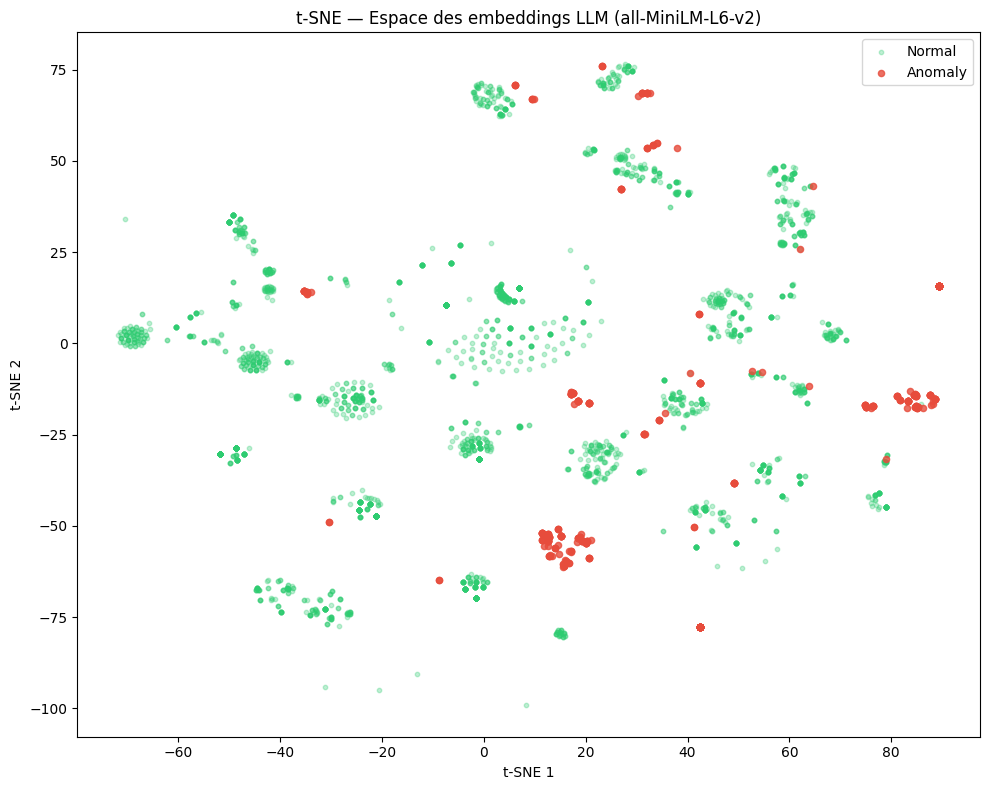

In [11]:
# t-SNE sur les embeddings LLM
print("Réduction t-SNE en cours... (peut prendre 1-2 min)")
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

fig, ax = plt.subplots(figsize=(10, 8))
scatter_normal = ax.scatter(
    X_tsne[y_sample == 0, 0], X_tsne[y_sample == 0, 1],
    c='#2ecc71', alpha=0.3, s=10, label='Normal'
)
scatter_anomaly = ax.scatter(
    X_tsne[y_sample == 1, 0], X_tsne[y_sample == 1, 1],
    c='#e74c3c', alpha=0.8, s=20, label='Anomaly'
)
ax.set_title('t-SNE — Espace des embeddings LLM (all-MiniLM-L6-v2)')
ax.legend()
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
plt.tight_layout()
plt.show()


#### 4.2 Comparaison PCA : TF-IDF et LLM
Projection des deux espaces de représentation pour le meme échantillon

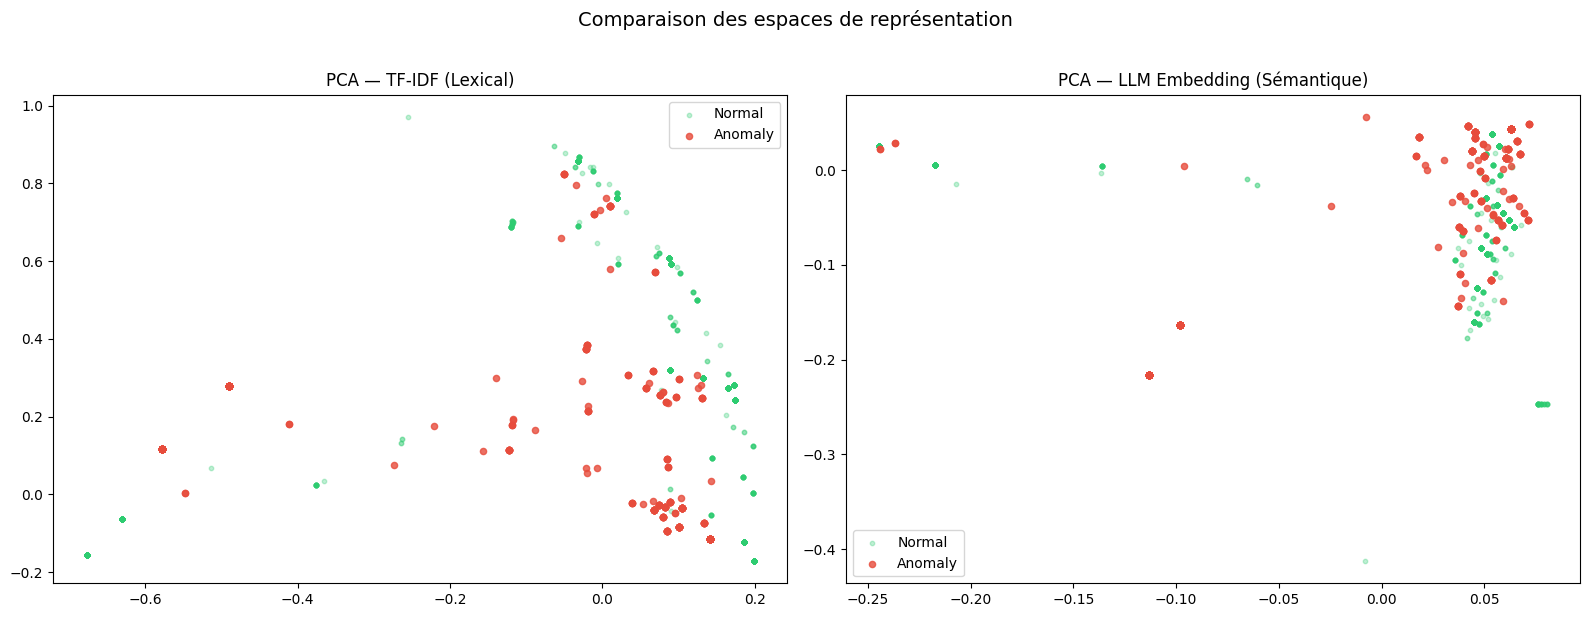

In [12]:
# Comparaison visuelle : TF-IDF vs LLM
# t-SNE sur TF-IDF (même échantillon)
from scipy.sparse import issparse

X_tfidf_all = ml_results['X_train_uni']  # Sparse matrix


pca = PCA(n_components=2, random_state=42)

# PCA sur LLM
X_pca_llm = pca.fit_transform(X_sample)

# PCA sur TF-IDF même échantillon => sequence_strings
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_temp = TfidfVectorizer(ngram_range=(1,1))
X_tfidf_temp = tfidf_temp.fit_transform([sequence_strings[i] for i in range(len(block_ids))])
X_tfidf_sample = X_tfidf_temp[sample_idx].toarray()
X_pca_tfidf = PCA(n_components=2, random_state=42).fit_transform(X_tfidf_sample)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, X_pca, title in [
    (axes[0], X_pca_tfidf, 'PCA — TF-IDF (Lexical)'),
    (axes[1], X_pca_llm, 'PCA — LLM Embedding (Sémantique)')
]:
    ax.scatter(X_pca[y_sample == 0, 0], X_pca[y_sample == 0, 1],
               c='#2ecc71', alpha=0.3, s=10, label='Normal')
    ax.scatter(X_pca[y_sample == 1, 0], X_pca[y_sample == 1, 1],
               c='#e74c3c', alpha=0.8, s=20, label='Anomaly')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Comparaison des espaces de représentation', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


#### 5. Tier 1 — Comparaison équitable (Régression Logistique)
Même classifier que le pipeline ML. Seule la représentation change.


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

# Préparation des données (mêmes indices que le pipeline ML)
X_train_emb = session_embeddings[train_idx]
X_test_emb = session_embeddings[test_idx]
X_train_8bit = session_embeddings_8bit[train_idx]
X_test_8bit = session_embeddings_8bit[test_idx]

print(f"Train embeddings : {X_train_emb.shape}")
print(f"Test embeddings  : {X_test_emb.shape}")


Train embeddings : (460048, 384)
Test embeddings  : (115013, 384)


#### 5.1 Expérience B1 : LLM Embedding (full) + Régression Logistique


In [14]:
# B1 : Embedding full precision + Régression Logistique
lr_b1 = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    solver='lbfgs'
)

t_start = time.time()
lr_b1.fit(X_train_emb, y_train)
t_train_b1 = time.time() - t_start

t_start = time.time()
y_pred_b1 = lr_b1.predict(X_test_emb)
t_pred_b1 = time.time() - t_start

print("=== B1 : LLM Embedding (full) + Régression Logistique ===")
print(f"Temps d'entraînement : {t_train_b1:.2f}s")
print(f"Temps de prédiction  : {t_pred_b1:.4f}s")
print(f"\n{classification_report(y_test, y_pred_b1, target_names=['Normal', 'Anomaly'])}")


=== B1 : LLM Embedding (full) + Régression Logistique ===
Temps d'entraînement : 10.65s
Temps de prédiction  : 0.3362s

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    111645
     Anomaly       0.90      1.00      0.95      3368

    accuracy                           1.00    115013
   macro avg       0.95      1.00      0.97    115013
weighted avg       1.00      1.00      1.00    115013



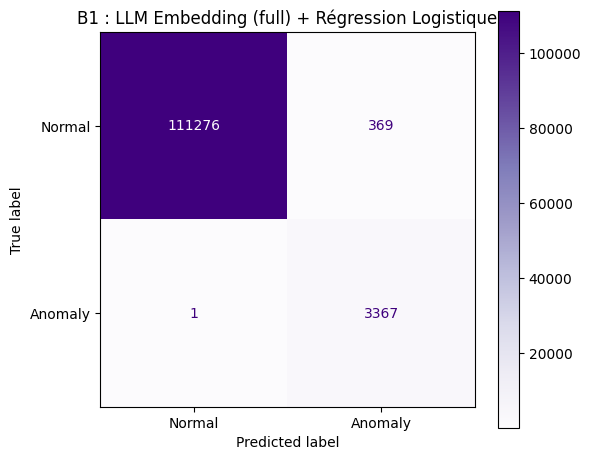

In [15]:
# Matrice de confusion — B1
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_b1,
    display_labels=['Normal', 'Anomaly'],
    cmap='Purples', ax=ax
)
ax.set_title('B1 : LLM Embedding (full) + Régression Logistique')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "cm_b1_llm_full_lr.png"))
plt.show()


#### 5.2 Expérience B2 : LLM Embedding (8-bit) + Régression Logistique


In [16]:
# B2 : Embedding 8-bit quantifié + Régression Logistique
lr_b2 = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
    solver='lbfgs'
)

t_start = time.time()
lr_b2.fit(X_train_8bit, y_train)
t_train_b2 = time.time() - t_start

t_start = time.time()
y_pred_b2 = lr_b2.predict(X_test_8bit)
t_pred_b2 = time.time() - t_start

print("=== B2 : LLM Embedding (8-bit) + Régression Logistique ===")
print(f"Temps d'entraînement : {t_train_b2:.2f}s")
print(f"Temps de prédiction  : {t_pred_b2:.4f}s")
print(f"\n{classification_report(y_test, y_pred_b2, target_names=['Normal', 'Anomaly'])}")


=== B2 : LLM Embedding (8-bit) + Régression Logistique ===
Temps d'entraînement : 9.43s
Temps de prédiction  : 0.4037s

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    111645
     Anomaly       0.90      0.99      0.94      3368

    accuracy                           1.00    115013
   macro avg       0.95      0.99      0.97    115013
weighted avg       1.00      1.00      1.00    115013



#### 6. Tier 2 — Scénario non supervisé (Isolation Forest)


In [17]:
from sklearn.ensemble import IsolationForest

# C2 : LLM Embedding + Isolation Forest
if_c2 = IsolationForest(
    n_estimators=100,
    contamination=0.03,
    random_state=42,
    n_jobs=-1
)

t_start = time.time()
if_c2.fit(X_train_emb)
t_train_c2 = time.time() - t_start

t_start = time.time()
y_pred_c2_raw = if_c2.predict(X_test_emb)
t_pred_c2 = time.time() - t_start

# Conversion : -1 (anomalie) → 1, 1 (normal) → 0
y_pred_c2 = [1 if p == -1 else 0 for p in y_pred_c2_raw]

print("=== C2 : LLM Embedding + Isolation Forest ===")
print(f"Temps d'entraînement : {t_train_c2:.2f}s")
print(f"Temps de prédiction  : {t_pred_c2:.4f}s")
print(f"\n{classification_report(y_test, y_pred_c2, target_names=['Normal', 'Anomaly'])}")


=== C2 : LLM Embedding + Isolation Forest ===
Temps d'entraînement : 4.78s
Temps de prédiction  : 1.4602s

              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98    111645
     Anomaly       0.37      0.38      0.38      3368

    accuracy                           0.96    115013
   macro avg       0.68      0.68      0.68    115013
weighted avg       0.96      0.96      0.96    115013



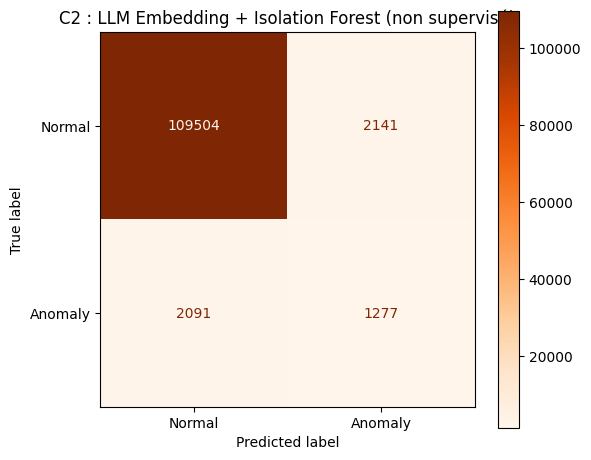

In [18]:
# Matrice de confusion — C2
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_c2,
    display_labels=['Normal', 'Anomaly'],
    cmap='Oranges', ax=ax
)
ax.set_title('C2 : LLM Embedding + Isolation Forest (non supervisé)')
plt.tight_layout()
plt.show()


#### 7. Tier 3 — Meilleure performance


In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC

# Random Forest + LLM embedding
rf_llm = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

t_start = time.time()
rf_llm.fit(X_train_emb, y_train)
t_train_rf_llm = time.time() - t_start

y_pred_rf_llm = rf_llm.predict(X_test_emb)

print("=== Tier 3 : LLM Embedding + Random Forest ===")
print(f"Temps d'entraînement : {t_train_rf_llm:.2f}s")
print(f"\n{classification_report(y_test, y_pred_rf_llm, target_names=['Normal', 'Anomaly'])}")


=== Tier 3 : LLM Embedding + Random Forest ===
Temps d'entraînement : 53.14s

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    111645
     Anomaly       1.00      1.00      1.00      3368

    accuracy                           1.00    115013
   macro avg       1.00      1.00      1.00    115013
weighted avg       1.00      1.00      1.00    115013



In [20]:
# Linear SVM + LLM embedding
svm_llm = LinearSVC(
    class_weight='balanced',
    random_state=42,
    max_iter=2000
)

t_start = time.time()
svm_llm.fit(X_train_emb, y_train)
t_train_svm_llm = time.time() - t_start

y_pred_svm_llm = svm_llm.predict(X_test_emb)

print("=== Tier 3 : LLM Embedding + Linear SVM ===")
print(f"Temps d'entraînement : {t_train_svm_llm:.2f}s")
print(f"\n{classification_report(y_test, y_pred_svm_llm, target_names=['Normal', 'Anomaly'])}")


=== Tier 3 : LLM Embedding + Linear SVM ===
Temps d'entraînement : 444.42s

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00    111645
     Anomaly       0.90      1.00      0.95      3368

    accuracy                           1.00    115013
   macro avg       0.95      1.00      0.97    115013
weighted avg       1.00      1.00      1.00    115013



#### 8. Comparaison complète — ML vs LLM


In [21]:
# Construction du tableau récapitulatif complet
all_experiments = {
    'Expérience': [
        'A1 — TF-IDF Uni + LR',
        'A2 — TF-IDF Bi + LR',
        'B1 — LLM Full + LR',
        'B2 — LLM 8-bit + LR',
        'C1 — TF-IDF + IF',
        'C2 — LLM + IF',
        'T3 — TF-IDF + RF',
        'T3 — TF-IDF + SVM',
        'T3 — LLM + RF',
        'T3 — LLM + SVM',
    ],
    'Tier': [
        'Tier 1', 'Tier 1', 'Tier 1', 'Tier 1',
        'Tier 2', 'Tier 2',
        'Tier 3', 'Tier 3', 'Tier 3', 'Tier 3',
    ],
    'Représentation': [
        'Lexicale', 'Lexicale', 'Sémantique', 'Sémantique',
        'Lexicale', 'Sémantique',
        'Lexicale', 'Lexicale', 'Sémantique', 'Sémantique',
    ],
    'Precision': [
        precision_score(y_test, ml_results['y_pred_a1']),
        precision_score(y_test, ml_results['y_pred_a2']),
        precision_score(y_test, y_pred_b1),
        precision_score(y_test, y_pred_b2),
        precision_score(y_test, ml_results['y_pred_c1']),
        precision_score(y_test, y_pred_c2),
        precision_score(y_test, ml_results['y_pred_rf']),
        precision_score(y_test, ml_results['y_pred_svm']),
        precision_score(y_test, y_pred_rf_llm),
        precision_score(y_test, y_pred_svm_llm),
    ],
    'Recall': [
        recall_score(y_test, ml_results['y_pred_a1']),
        recall_score(y_test, ml_results['y_pred_a2']),
        recall_score(y_test, y_pred_b1),
        recall_score(y_test, y_pred_b2),
        recall_score(y_test, ml_results['y_pred_c1']),
        recall_score(y_test, y_pred_c2),
        recall_score(y_test, ml_results['y_pred_rf']),
        recall_score(y_test, ml_results['y_pred_svm']),
        recall_score(y_test, y_pred_rf_llm),
        recall_score(y_test, y_pred_svm_llm),
    ],
    'F1-Score': [
        f1_score(y_test, ml_results['y_pred_a1']),
        f1_score(y_test, ml_results['y_pred_a2']),
        f1_score(y_test, y_pred_b1),
        f1_score(y_test, y_pred_b2),
        f1_score(y_test, ml_results['y_pred_c1']),
        f1_score(y_test, y_pred_c2),
        f1_score(y_test, ml_results['y_pred_rf']),
        f1_score(y_test, ml_results['y_pred_svm']),
        f1_score(y_test, y_pred_rf_llm),
        f1_score(y_test, y_pred_svm_llm),
    ],
}

df_all = pd.DataFrame(all_experiments)
print("=" * 80)
print("TABLEAU RÉCAPITULATIF COMPLET — ML vs LLM")
print("=" * 80)
display(df_all.round(4))

# Sauvegarde
df_all.to_csv(os.path.join(OUTPUT_DIR, "all_results_table.csv"), index=False)


TABLEAU RÉCAPITULATIF COMPLET — ML vs LLM


,Expérience,Tier,Représentation,Precision,Recall,F1-Score
0,A1 — TF-IDF Uni + LR,Tier 1,Lexicale,0.9601,0.9994,0.9793
1,A2 — TF-IDF Bi + LR,Tier 1,Lexicale,0.9541,0.9994,0.9762
2,B1 — LLM Full + LR,Tier 1,Sémantique,0.9012,0.9997,0.9479
3,B2 — LLM 8-bit + LR,Tier 1,Sémantique,0.9005,0.9914,0.9438
4,C1 — TF-IDF + IF,Tier 2,Lexicale,0.6283,0.5665,0.5958
5,C2 — LLM + IF,Tier 2,Sémantique,0.3736,0.3792,0.3764
6,T3 — TF-IDF + RF,Tier 3,Lexicale,0.9985,0.9991,0.9988
7,T3 — TF-IDF + SVM,Tier 3,Lexicale,0.9645,0.9997,0.9818
8,T3 — LLM + RF,Tier 3,Sémantique,0.9982,0.9991,0.9987
9,T3 — LLM + SVM,Tier 3,Sémantique,0.9013,1.0000,0.9481


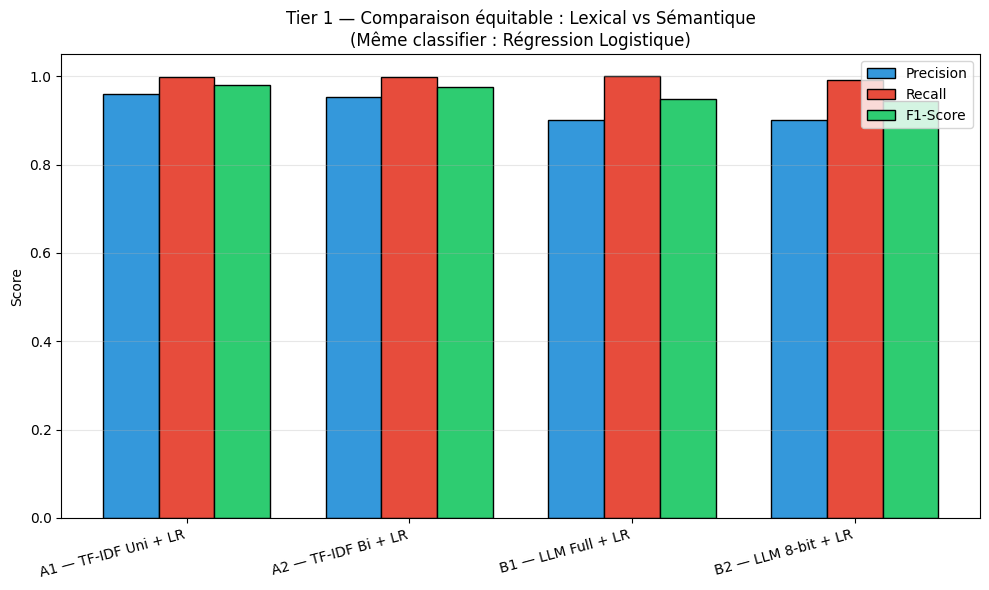

In [23]:
# Visualisation comparative Tier 1 : Lexical vs Sémantique
tier1 = df_all[df_all['Tier'] == 'Tier 1'].copy()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(tier1))
width = 0.25

ax.bar(x - width, tier1['Precision'], width, label='Precision', color='#3498db', edgecolor='black')
ax.bar(x, tier1['Recall'], width, label='Recall', color='#e74c3c', edgecolor='black')
ax.bar(x + width, tier1['F1-Score'], width, label='F1-Score', color='#2ecc71', edgecolor='black')

ax.set_ylabel('Score')
ax.set_title('Tier 1 — Comparaison équitable : Lexical vs Sémantique\n(Même classifier : Régression Logistique)')
ax.set_xticks(x)
ax.set_xticklabels(tier1['Expérience'], rotation=15, ha='right')
ax.legend()
ax.set_ylim(0, 1.05)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "tier1_full_comparison.png"))
plt.show()


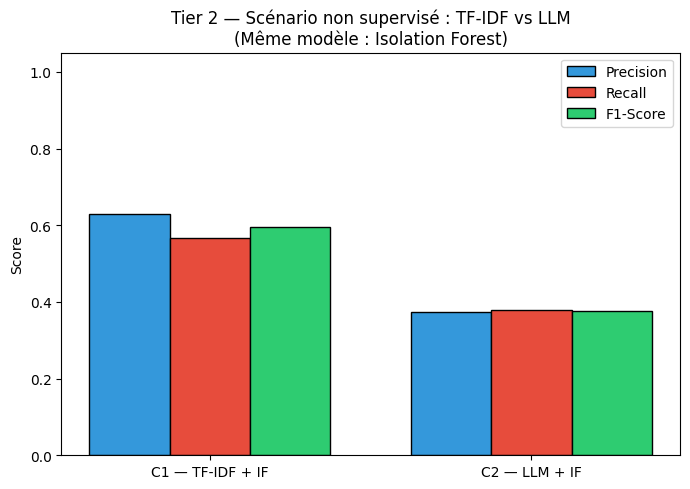

In [24]:
# Visualisation Tier 2 : Unsupervised
tier2 = df_all[df_all['Tier'] == 'Tier 2']

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(len(tier2))
width = 0.25

ax.bar(x - width, tier2['Precision'], width, label='Precision', color='#3498db', edgecolor='black')
ax.bar(x, tier2['Recall'], width, label='Recall', color='#e74c3c', edgecolor='black')
ax.bar(x + width, tier2['F1-Score'], width, label='F1-Score', color='#2ecc71', edgecolor='black')

ax.set_ylabel('Score')
ax.set_title('Tier 2 — Scénario non supervisé : TF-IDF vs LLM\n(Même modèle : Isolation Forest)')
ax.set_xticks(x)
ax.set_xticklabels(tier2['Expérience'])
ax.legend()
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "tier2_comparison.png"))
plt.show()


#### 9. Analyse croisée des erreurs — ML vs LLM
Identification des cas où les deux approches divergent.


In [25]:
# Analyse croisée des prédictions Tier 1 (A1 vs B1)
test_block_ids = [block_ids[i] for i in test_idx]
y_pred_a1 = ml_results['y_pred_a1']

# Catégorisation des résultats
both_correct = []    # Les deux détectent
only_tfidf = []      # TF-IDF détecte, LLM manque
only_llm = []        # LLM détecte, TF-IDF manque
both_missed = []     # Les deux manquent

for i in range(len(y_test)):
    if y_test[i] == 1:  # Vraie anomalie
        tfidf_ok = (y_pred_a1[i] == 1)
        llm_ok = (y_pred_b1[i] == 1)
        
        if tfidf_ok and llm_ok:
            both_correct.append(i)
        elif tfidf_ok and not llm_ok:
            only_tfidf.append(i)
        elif not tfidf_ok and llm_ok:
            only_llm.append(i)
        else:
            both_missed.append(i)

print("=== Analyse croisée A1 (TF-IDF) vs B1 (LLM) ===")
print(f"Total anomalies test :              {sum(y_test):,}")
print(f"Détectées par les deux :            {len(both_correct):,}")
print(f"Uniquement par TF-IDF :             {len(only_tfidf):,}")
print(f"Uniquement par LLM :                {len(only_llm):,}")
print(f"Manquées par les deux :             {len(both_missed):,}")


=== Analyse croisée A1 (TF-IDF) vs B1 (LLM) ===
Total anomalies test :              3,368
Détectées par les deux :            3,365
Uniquement par TF-IDF :             1
Uniquement par LLM :                2
Manquées par les deux :             0


In [27]:
# Examen des cas "uniquement LLM" (avantage sémantique)
print("=" * 75)
print("ANOMALIES DÉTECTÉES UNIQUEMENT PAR LLM (pas par TF-IDF)")
print("=" * 75)

for idx in only_llm[:5]:
    bid = test_block_ids[idx]
    s = enriched_sessions[bid]
    print(f"\n {bid}  [{len(s['events'])} événements]")
    print(f"   Séquence : {s['sequence_str'][:100]}...")
    print()


ANOMALIES DÉTECTÉES UNIQUEMENT PAR LLM (pas par TF-IDF)

 blk_2429961036831384938  [15 événements]
   Séquence : E2 E1 E1 E1 E3 E4 E5 E12 E11 E3 E4 E3 E4 E5 E5...


 blk_-1791865405548036877  [15 événements]
   Séquence : E1 E2 E1 E1 E3 E4 E5 E3 E4 E3 E4 E5 E11 E12 E5...



In [29]:
# Examen des cas "uniquement TF-IDF" (avantage lexical)
print("=" * 75)
print("ANOMALIES DÉTECTÉES UNIQUEMENT PAR TF-IDF (pas par LLM)")
print("=" * 75)

for idx in only_tfidf[:5]:
    bid = test_block_ids[idx]
    s = enriched_sessions[bid]
    print(f"\n {bid}  [{len(s['events'])} événements]")
    print(f"   Séquence : {s['sequence_str'][:100]}...")
    print()

if not only_tfidf:
    print("\n(Aucun cas trouvé)")


ANOMALIES DÉTECTÉES UNIQUEMENT PAR TF-IDF (pas par LLM)

 blk_3709643589615046481  [13 événements]
   Séquence : E1 E2 E1 E1 E38 E3 E15 E24 E14 E3 E3 E19 E20...



In [33]:
# Classification des anomalies par type
def classify_anomaly_type(seq_str):
    """Classification règle-basée des types d'anomalies HDFS."""
    tokens = seq_str.split()
    has_error_events = any(e in seq_str for e in ['E16', 'E19', 'E20', 'E44', 'E46', 'E47'])
    has_serving_exception = 'E35' in seq_str
    has_delete_error = 'E33' in seq_str
    is_short = len(tokens) <= 4
    
    if is_short:
        return 'Cycle de vie incomplet'
    elif has_error_events:
        return 'Erreur d\'écriture'
    elif has_serving_exception:
        return 'Exception de service'
    elif has_delete_error:
        return 'Erreur de suppression'
    else:
        return 'Autre'

# Typage de toutes les anomalies du test set
anomaly_test_idx = [i for i, y in enumerate(y_test) if y == 1]
anomaly_types = {}

for i in anomaly_test_idx:
    bid = test_block_ids[i]
    seq = enriched_sessions[bid]['sequence_str']
    atype = classify_anomaly_type(seq)
    if atype not in anomaly_types:
        anomaly_types[atype] = {'total': 0, 'tfidf_ok': 0, 'llm_ok': 0}
    anomaly_types[atype]['total'] += 1
    if y_pred_a1[i] == 1:
        anomaly_types[atype]['tfidf_ok'] += 1
    if y_pred_b1[i] == 1:
        anomaly_types[atype]['llm_ok'] += 1

# Tableau par type d'anomalie
print("\n=== Taux de détection par type d'anomalie ===")
print(f"{'Type':<30} {'Total':>6} {'TF-IDF':>10} {'LLM':>10} {'delta':>10}")
print("-" * 70)
for atype, counts in sorted(anomaly_types.items(), key=lambda x: -x[1]['total']):
    total = counts['total']
    tfidf_rate = counts['tfidf_ok'] / total * 100
    llm_rate = counts['llm_ok'] / total * 100
    delta = llm_rate - tfidf_rate
    print(f"{atype:<30} {total:>6} {tfidf_rate:>9.1f}% {llm_rate:>9.1f}%{delta:>+9.1f}%")



=== Taux de détection par type d'anomalie ===
Type                            Total     TF-IDF        LLM      delta
----------------------------------------------------------------------
Cycle de vie incomplet           1230     100.0%     100.0%     +0.0%
Erreur de suppression             804     100.0%     100.0%     +0.0%
Autre                             675      99.7%     100.0%     +0.3%
Exception de service              645     100.0%     100.0%     +0.0%
Erreur d'écriture                  14     100.0%      92.9%     -7.1%
